# Хаос в пищевой цепи

## Базовый уровень

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Обезразмеренная модель по Hastings и Powell:

\begin{equation*}
\begin{cases}
\frac{dx}{dt} = x (1 - x) - f_1(x) y\\
\frac{dy}{dt} = f_1(x) y - f_2(y) z - d_1 y\\
\frac{dz}{dt} = f_2(y) z - d_2 z
\end{cases}
,
\end{equation*}

где $f_1(x) = \frac{a_1 x}{b_1 x + 1}$, $f_2(y) = \frac{a_2 y}{b_2 y + 1}$.


Проинтегрируем систему с помощью RK45 для стандартных параметров $a_1 = 5$, $b_1 = 3$, $a_2 = 0.1$, $b_2 = 2$, $d_1 = 0.4$, $d_2 = 0.01$ и начальных условий $x(0) = 0.5$, $y(0) = 0.1$, $z(0) = 0.1$.

In [2]:
a1 = 5.0
b1 = 3.0
a2 = 0.1
b2 = 2.0
d1 = 0.4
d2 = 0.01

T = 5000.0
n_steps = 10000

x0, y0, z0 = 0.5, 0.1, 0.1
y0_vec = [x0, y0, z0]

def f1(x):
    return a1 * x / (1.0 + b1 * x)

def f2(y):
    return a2 * y / (1.0 + b2 * y)

def f(t, v):
    x, y, z = v
    dxdt = x * (1 - x) - f1(x) * y
    dydt = f1(x) * y - f2(y) * z - d1 * y
    dzdt = f2(y) * z - d2 * z
    return [dxdt, dydt, dzdt]

t_span = (0.0, T)
t_eval = np.linspace(t_span[0], t_span[1], n_steps + 1)

sol = solve_ivp(f, t_span, y0_vec, t_eval=t_eval, method='RK45')

Визуализируем графики временных рядов для решённой системы.

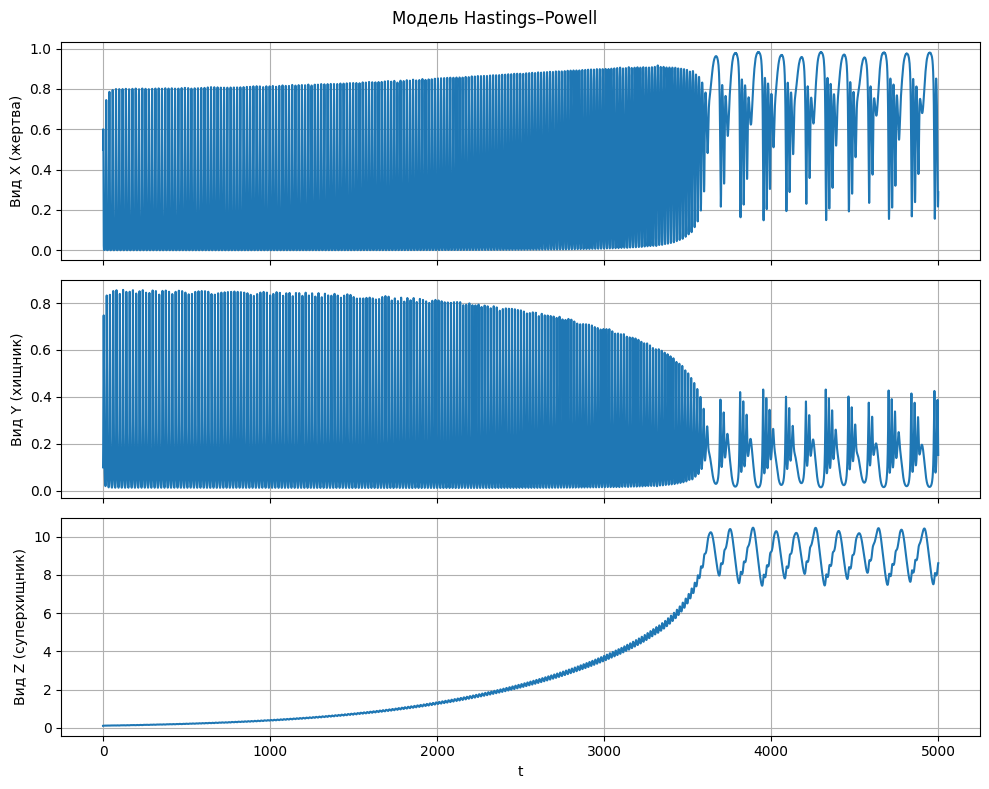

In [3]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
axs[0].plot(sol.t, sol.y[0])
axs[0].set_ylabel('Вид X (жертва)')
axs[0].grid(True)

axs[1].plot(sol.t, sol.y[1])
axs[1].set_ylabel('Вид Y (хищник)')
axs[1].grid(True)

axs[2].plot(sol.t, sol.y[2])
axs[2].set_ylabel('Вид Z (суперхищник)')
axs[2].set_xlabel('t')
axs[2].grid(True)

fig.suptitle('Модель Hastings–Powell', fontsize=12)
plt.tight_layout()
plt.show()

Из графиков видно, что перед установлением (квази)периодических колебаний система испытывает некоторое переходное поведение. Поэтому будем выводить графики только за последние 1500 единиц времени.

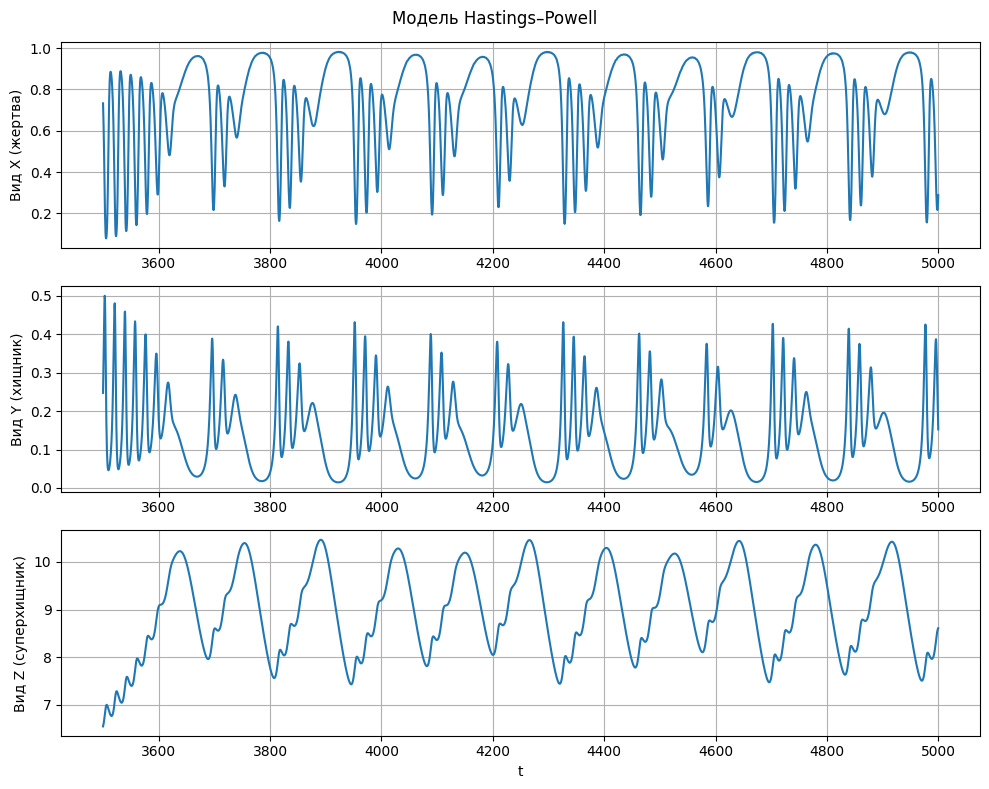

In [4]:
tmin = T - 1500
tmax = T
mask = (sol.t >= tmin) & (sol.t <= tmax)

fig, axs = plt.subplots(3, 1, figsize=(10, 8))
axs[0].plot(sol.t[mask], sol.y[0][mask])
axs[0].set_ylabel('Вид X (жертва)')
axs[0].grid(True)

axs[1].plot(sol.t[mask], sol.y[1][mask])
axs[1].set_ylabel('Вид Y (хищник)')
axs[1].grid(True)

axs[2].plot(sol.t[mask], sol.y[2][mask])
axs[2].set_ylabel('Вид Z (суперхищник)')
axs[2].set_xlabel('t')
axs[2].grid(True)

fig.suptitle('Модель Hastings–Powell', fontsize=12)
plt.tight_layout()
plt.show()

Визуализируем фазовый портрет и его проекции на двумерные координатные плоскости.

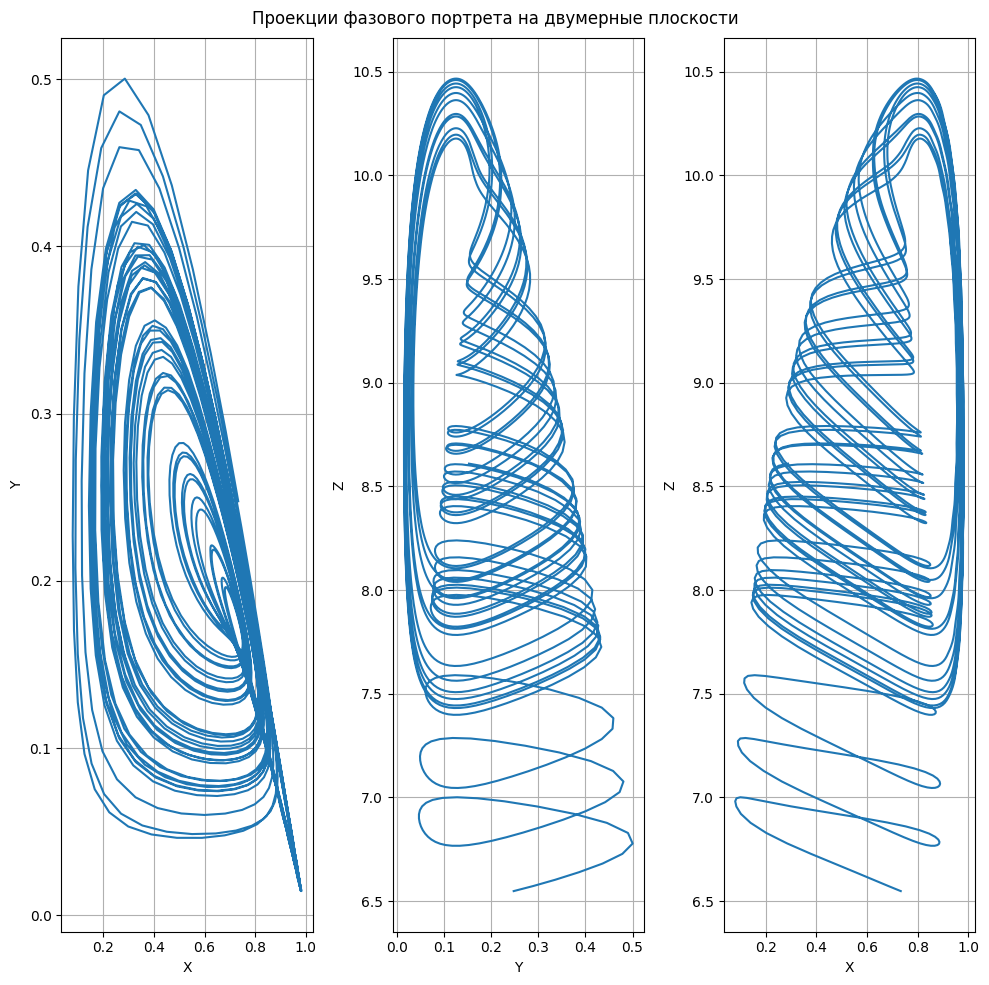

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(10, 10))
axs[0].plot(sol.y[0][mask], sol.y[1][mask])
axs[0].set_xlabel('X')
axs[0].set_ylabel('Y')
axs[0].grid(True)

axs[1].plot(sol.y[1][mask], sol.y[2][mask])
axs[1].set_xlabel('Y')
axs[1].set_ylabel('Z')
axs[1].grid(True)

axs[2].plot(sol.y[0][mask], sol.y[2][mask])
axs[2].set_xlabel('X')
axs[2].set_ylabel('Z')
axs[2].grid(True)

fig.suptitle('Проекции фазового портрета на двумерные плоскости', fontsize=12)
plt.tight_layout()
plt.show()

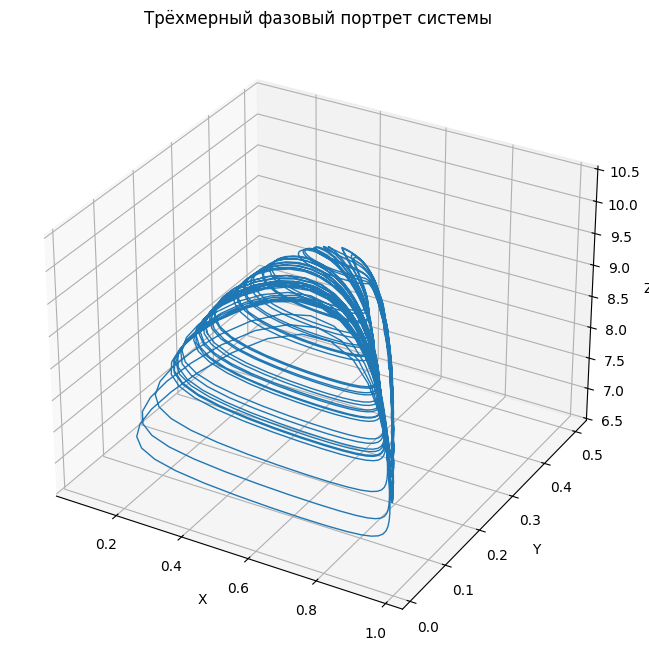

In [6]:
ax = plt.figure(figsize=(8, 8)).add_subplot(projection='3d')

ax.plot(sol.y[0][mask], sol.y[1][mask], sol.y[2][mask], lw=1.0)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title('Трёхмерный фазовый портрет системы')

plt.show()